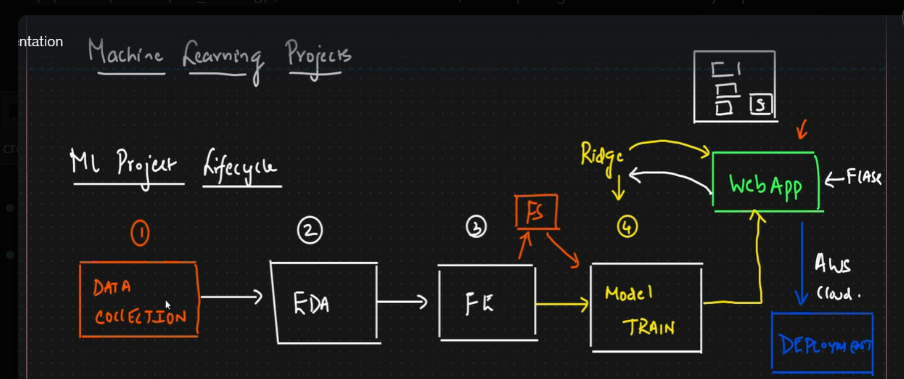

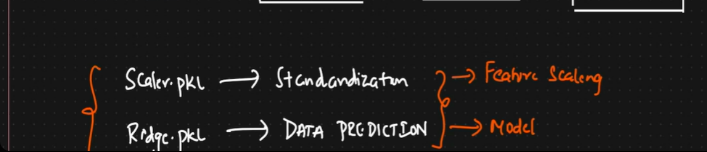

## ML Project Lifecycle (End-to-End)

```
 (1)              (2)             (3)            (4)                              
+-----------+    +-------+    +---------+    +-----------+   Ridge   +------------+       +----------+
|   Data    | -> |  EDA  | -> |   FE    | -> |   Model   | <-------> |  Web App   |  AWS  |          |
|Collection |    |       |    |(Feature |    |   Train   |           | (Flask)    | Cloud | Deployment|
+-----------+    +-------+    | Scaling)|    +-----------+           +------------+ ----> |          |
                               +---------+                                                +----------+
```

**Stage-by-stage, mapped to this notebook:**

1. **Data Collection** — raw `Algerian_forest_fires` dataset (two regions, stacked with a duplicate header row).
2. **EDA** — cleaning (`dropna`, dropping the stray duplicate header row, type casting object columns to `float`), plus correlation analysis (`sns.heatmap`, the `correlation()` function) to spot multicollinearity like `DMC`/`DC`/`BUI`.
3. **FE (Feature Engineering)** — dropping `day`/`month`/`year`, dropping the correlated `{'BUI', 'DC'}` columns, and **Feature Scaling** via `StandardScaler` (fit on `X_train`, applied to both `X_train`/`X_test`).
4. **Model Train** — fitting Linear Regression, Ridge/RidgeCV, Lasso/LassoCV, ElasticNet/ElasticNetCV and comparing MAE/R² to select the best model (Ridge/RidgeCV, given its stability under multicollinearity). This step produces the two deployment artifacts:
   - **`scaler.pkl`** → the fitted `StandardScaler` → handles **Standardization / Feature Scaling** for any new input at inference time.
   - **`ridge.pkl`** → the fitted Ridge model → handles **Data Prediction** (the actual `model.predict(...)` call).
5. **Web App (Flask)** — loads both `scaler.pkl` and `ridge.pkl`, takes raw user input, scales it (`scaler.transform`, never `fit_transform`), feeds it to `ridge.predict(...)`, and returns the prediction (predicted FWI) back to the user.
6. **AWS Cloud / Deployment** — the Flask app is hosted on cloud infrastructure (e.g. AWS EC2/Elastic Beanstalk) so it's reachable over the internet, completing the loop from raw data all the way to a live, user-facing prediction service.

**Key takeaway:** steps 1-4 happen once, offline, in this notebook. Steps 5-6 happen repeatedly, online, per user request — and they only work correctly because `scaler.pkl` and `ridge.pkl` are the exact frozen artifacts produced back in step 4, loaded as-is (no refitting) for every new prediction.

# Explanation of `application.py`

This notebook walks through the Flask app in `application.py` section by section. It serves a Fire Weather Index (FWI) prediction form and returns a prediction from a pre-trained Ridge regression model.

## 1. Run instructions

Comments at the top of the file documenting how to start the app and which URL serves the prediction form.

In [ ]:
# run from terminal C:\Users\satya\flask_lab\venvScripts\python.exe application.py
#link - http://127.0.0.1:5000/predictdata

## 2. Imports

- `pickle` loads the previously trained model and scaler objects from disk.
- `Flask`, `request`, `jsonify`, `render_template` are the core Flask building blocks used to build routes, read form data, and render HTML templates.
- `numpy` and `pandas` are general array/data-handling utilities.
- `StandardScaler` is imported for type reference; the actual scaler instance used at runtime is unpickled from `models/scaler.pkl`, not constructed here.

In [ ]:
import pickle
from flask import Flask, request, jsonify, render_template
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

## 3. Flask app initialization

Creates the Flask application instance. `app` is just an alias for `application`, which is a common convention for WSGI deployment platforms (e.g. AWS Elastic Beanstalk) that expect the entry-point object to be named `application`.

In [ ]:
application = Flask(__name__)
app = application

## 4. Loading the trained model and scaler

Loads two artifacts saved from an earlier training run:
- `ridge_model`: a fitted `sklearn.linear_model.Ridge` regressor used to predict the FWI value.
- `standard_scaler`: a fitted `StandardScaler` used to normalize incoming feature values the same way the training data was normalized.

Both are loaded once at import time so every request reuses the same in-memory objects instead of reloading from disk.

In [ ]:
## import ridge regressor and standard scaler pickle
ridge_model = pickle.load(open('models/ridge.pkl', 'rb'))
standard_scaler = pickle.load(open('models/scaler.pkl', 'rb'))

## 5. Home route (`/`)

Serves `templates/index.html` (a simple landing page) when a user visits the root URL.

In [ ]:
@app.route("/")
def index():
    return render_template('index.html')

## 6. Prediction route (`/predictdata`)

This route accepts both `GET` and `POST`:
- `GET` (e.g. a normal page visit) just renders the blank `home.html` form.
- `POST` (form submission) runs the prediction logic covered in the next sections and re-renders `home.html` with the result.

In [ ]:
@app.route('/predictdata', methods=['GET', 'POST'])
def predict_datapoint():
    if request.method == "POST":
        Temperature = float(request.form.get('Temperature'))
        RH = float(request.form.get('RH'))
        Ws = float(request.form.get('Ws'))
        Rain = float(request.form.get('Rain'))
        FFMC = float(request.form.get('FFMC'))
        DMC = float(request.form.get('DMC'))
        ISI = float(request.form.get('ISI'))
        Classes = float(request.form.get('Classes'))
        Region = float(request.form.get('Region'))

        new_data_scaled = standard_scaler.transform([[Temperature, RH, Ws, Rain, FFMC, DMC, ISI, Classes, Region]])
        result = ridge_model.predict(new_data_scaled)

        return render_template('home.html', results=result[0])
    else:
        return render_template('home.html')

## 7. Reading form inputs

Pulls each of the nine input fields out of the submitted HTML form (`request.form`) and converts them from strings to floats. These correspond to the weather/fire-index features the model was trained on: Temperature, Relative Humidity, Wind Speed, Rain, and the FWI sub-indices (FFMC, DMC, ISI), plus `Classes` and `Region`.

In [ ]:
Temperature = float(request.form.get('Temperature'))
RH = float(request.form.get('RH'))
Ws = float(request.form.get('Ws'))
Rain = float(request.form.get('Rain'))
FFMC = float(request.form.get('FFMC'))
DMC = float(request.form.get('DMC'))
ISI = float(request.form.get('ISI'))
Classes = float(request.form.get('Classes'))
Region = float(request.form.get('Region'))

## 8. Scaling and predicting

The nine values are assembled into a single-row 2D array (the shape `sklearn` expects), scaled with the same `StandardScaler` used during training, and then passed to the Ridge model to get a predicted FWI value.

In [ ]:
new_data_scaled = standard_scaler.transform([[Temperature, RH, Ws, Rain, FFMC, DMC, ISI, Classes, Region]])
result = ridge_model.predict(new_data_scaled)

## 9. Returning the result

`result` is a NumPy array with one element (since one row was predicted), so `result[0]` extracts the scalar prediction. It's passed into `home.html` as the `results` template variable, which the page displays as "THE FWI prediction is {{results}}".

In [ ]:
return render_template('home.html', results=result[0])

## 10. Running the app

Starts Flask's development server when the script is run directly (not imported). `host="0.0.0.0"` binds to all network interfaces, making the app reachable from other devices on the same network, not just `localhost`.

In [ ]:
if __name__ == "__main__":
    app.run(host="0.0.0.0")

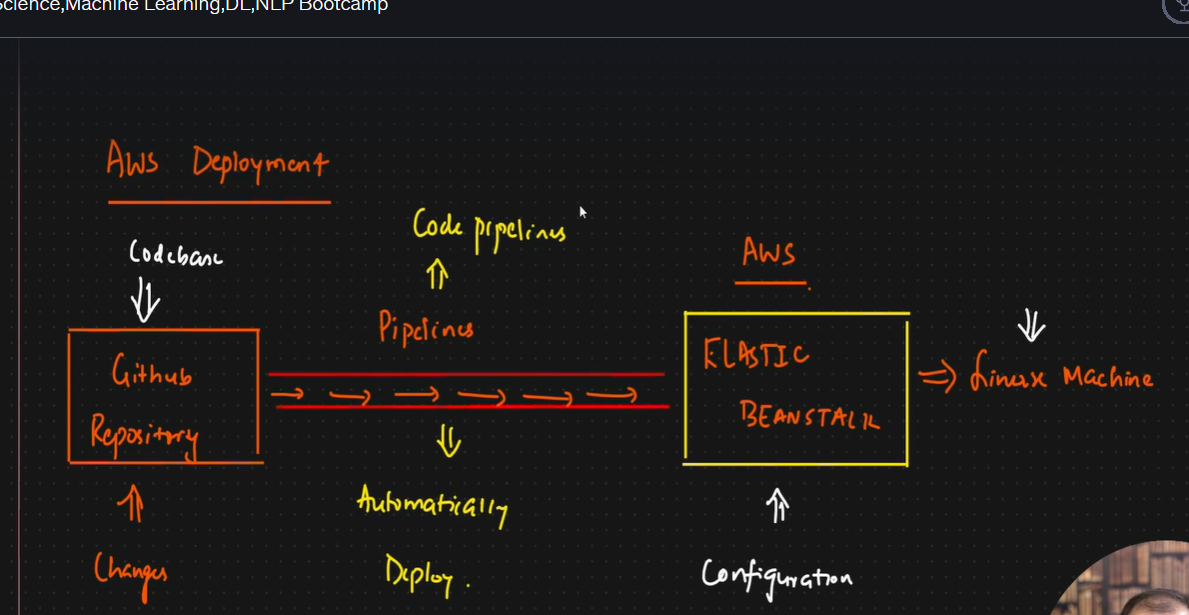

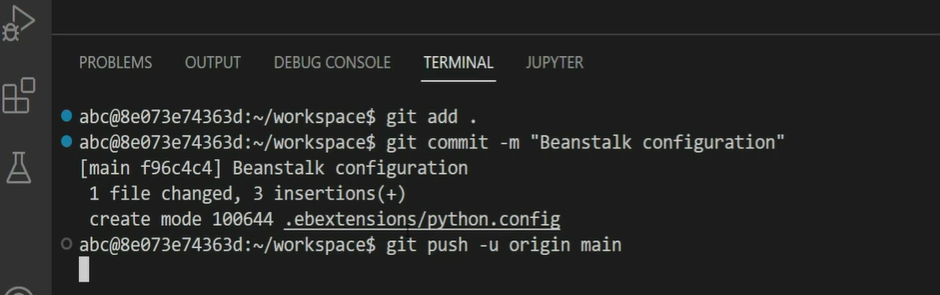

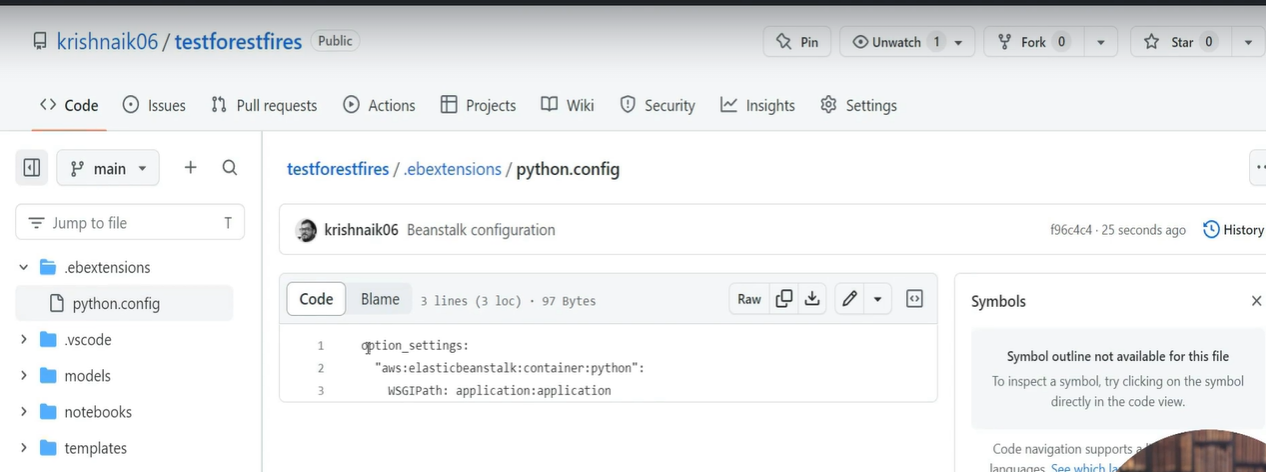